Step 1: Explore and prepare data!

In [80]:
import pandas as pd

df = pd.read_csv("ML_dataset.csv")
to_drop = ['id','title','best_picture_nom','nominated','won','audience_rating','revenue','cast'] #consider dropping revenue 
df = df.drop(columns=to_drop)

In [81]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45369 entries, 0 to 45368
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                45369 non-null  int64  
 1   budget              45369 non-null  float64
 2   runtime             45369 non-null  float64
 3   genres              45369 non-null  str    
 4   director            45369 non-null  str    
 5   tomatometer_rating  45369 non-null  float64
dtypes: float64(3), int64(1), str(2)
memory usage: 2.1 MB


In [82]:
from sklearn.model_selection import train_test_split
X = df.drop(columns='tomatometer_rating')
y = df['tomatometer_rating']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, stratify=y, random_state=12)

Step 2: Build a pipeline of training


In [83]:
from sklearn.pipeline import Pipeline 
from category_encoders.target_encoder import TargetEncoder
from xgboost import XGBRegressor 

estimators = [
    ('encoder', TargetEncoder()), #turns categorical data into numerical data
    ('clf', XGBRegressor(random_state=12))
]

pipe = Pipeline(steps=estimators)
pipe 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('encoder', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,None
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,min_samples_leaf,20


Step 3: Set up hyperparameter tuning (to be fixed...maybe...)


In [84]:
from skopt import BayesSearchCV 
from skopt.space import Real,Integer 

#Start by tuning learning rate, maximum tree depth, and number of estimators 
search_space = {
    'encoder__smoothing':Real(1,100, prior='uniform'),
    'clf__max_depth': Integer(2,10),
    'clf__n_estimators': Integer(100,1000),
    'clf__learning_rate': Real(0.001,1.00,prior='log-uniform')
}

opt = BayesSearchCV(pipe,search_space,cv=5,n_iter=50,scoring='neg_mean_absolute_error',random_state=12,n_jobs=-1)
opt.fit(X_train,y_train)


,estimator,"Pipeline(step...=None, ...))])"
,search_spaces,"{'clf__learning_rate': Real(low=0.00...m='normalize'), 'clf__max_depth': Integer(low=2...m='normalize'), 'clf__n_estimators': Integer(low=1...m='normalize'), 'encoder__smoothing': Real(low=1, h...m='normalize')}"
,optimizer_kwargs,None
,n_iter,50
,scoring,'neg_mean_absolute_error'
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,5


Step 5: Evaulate the model and make predictions

In [85]:
opt.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('encoder', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,"['genres', 'director']"
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,min_samples_leaf,20


In [86]:
opt.best_score_

np.float64(-8.859613727317859)

In [87]:
opt.best_params_

OrderedDict([('clf__learning_rate', 0.0013386569252924335),
             ('clf__max_depth', 9),
             ('clf__n_estimators', 327),
             ('encoder__smoothing', 1.0)])

In [88]:
opt.predict(X_test)

array([62.688305, 63.683735, 62.172535, ..., 65.30568 , 63.65934 ,
       70.61209 ], shape=(9074,), dtype=float32)

In [89]:
opt.score(X_test,y_test)

-8.836806822590347

Step 6: Measure feature importance

In [90]:
opt.best_estimator_.steps

[('encoder', TargetEncoder(cols=['genres', 'director'], smoothing=1.0)),
 ('clf',
  XGBRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.0013386569252924335, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=9, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=327, n_jobs=None,
               num_parallel_tree=None, ...))]

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

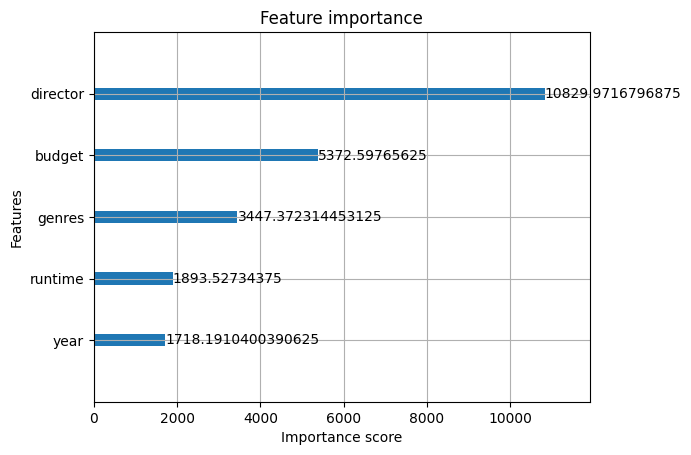

In [91]:
from xgboost import plot_importance

xgboost_step = opt.best_estimator_.steps[1]
xgboost_model = xgboost_step[1]
plot_importance(xgboost_model,importance_type='gain')